In [1]:
import socket
print(socket.gethostname())

fc30603


In [2]:
import numpy as np
import torch
import scipy.linalg as linalg
import matplotlib.pyplot as plt
print(f"NumPy:  {np.__version__}")
print(f"PyTorch: {torch.__version__}")

NumPy:  1.25.2
PyTorch: 2.0.1


In [3]:
def gaussian3d(x,mean,covar = np.array([[5,0,0],[0,5,0],[0,0,5]])):

    '''
    returns a 3d gaussian evaluated for an image and time location with a given covariance matrix and mean
    '''
    

    Ninv = np.linalg.pinv(covar)

    return np.exp(-np.diag((x-mean).T@Ninv@(x-mean))) ## there's probably a smarter way to do this
    #Normalized: 

    #return ((2*np.pi)**-1.5)*(np.linalg.det(covar)**-0.5)*np.exp(-0.5*np.diag((x-mean).T@Ninv@(x-mean)))


def genrandomfield(xlen,ylen,tlen,Ntrans,widths = None,noiseamp = 0.1):

    '''
    generates a field of white noise with a given number of overlaid gaussian 'transients'.
    Transients and noise returned as separate layers. 

    Arguements (in order):

    xlen: length of the first image dimension, in pixels
    ylen: same as above but for second dimension
    tlen: length of the image/noise fields to be generated, in time (arbitrary units)
    Ntrans: how many transients to simulate
    widths: a 3-tuple (A,B,C) of sigma values corresponding to the x, y and time widths of the 3D Gaussian transients.
    for example, widths = (1,2,10) will give transients that are narrow in the first image dimension, broader in the second,
    and have a characteristic timescale of about 10 time units.
    noiseamp: the root-mean-square level of (white) noise in the image.

    returns: (in order)
    combinedfield, noisefield+transient_field
    noisefield: the noise layer, with shape (xlen,ylen,tlen)
    transient_field: the transient layer, with shape (xlen,ylen,tlen)
    x0: the list of positions of each source in the first image axis
    y0: the list of positions of each source in the second image axis
    t0: the central times of each transient signal (time of peak brightness)
    '''

    x = np.arange(xlen) ## x and y arrays
    y = np.arange(ylen)

    xx,yy = np.meshgrid(x,y) ## create a grid of x,y positions to evaluate at

    xxf,yyf = xx.ravel(),yy.ravel() ## flatten for processing

    rng = np.random.default_rng()

    noisefield = noiseamp*rng.standard_normal(size = (xlen,ylen,tlen)) # generate the noise

    transient_field = np.zeros(noisefield.shape) ## array for the transient layer to be created in
    combined_field = np.zeros(noisefield.shape)

    gaussian_parameters = [] #record the gaussian target parameter in the form of x_mean, y_mean, t_mean, x_std, y_std, t_std

    x0 = [] ## these record the x, y, and time mean values for each transient signal
    y0 = [] ## these record the x, y, and time mean values for each transient signal
    t0 = [] ## these record the x, y, and time mean values for each transient signal

    #x_std = [] #record gaussian std on x
    #y_std = [] #record gaussian std on y
    #t_std = [] #record gaussian std on t

    posvecs = np.zeros((3,len(xxf)))
    posvecs[0,:] = xxf
    posvecs[1,:] = yyf
    
    for i in range(Ntrans):

        x0.append(np.random.randint(xlen)) ## record where this trans happened
        y0.append(np.random.randint(ylen))
        t0.append(np.random.randint(tlen))
        widths[0] = np.random.randint(1, xlen/4)
        widths[1] = np.random.randint(1, ylen/4)
        widths[2] = np.random.randint(1, tlen/4)

        if widths:
            covar = np.array([[widths[0]**2,0,0],[0,widths[1]**2,0],[0,0,widths[2]**2]])

        for t in range(tlen):

            posvecs[2,:] = t

            if widths:

                trans = gaussian3d(posvecs, mean = np.array([[x0[-1],y0[-1],t0[-1]]]).T, covar = covar).reshape((xlen,ylen))
            else:

                trans = gaussian3d(posvecs, mean = np.array([[x0[-1],y0[-1],t0[-1]]]).T).reshape((xlen,ylen))

            transient_field[:,:,t] += trans
            combined_field[:,:,t] = transient_field[:,:,t] + noisefield[:,:,t]

        gaussian_parameters.append(np.vstack((x0[-1], y0[-1], t0[-1], widths[0], widths[1], widths[2])))
    
    gaussian_parameters = np.array(gaussian_parameters)
    return combined_field, noisefield,transient_field,gaussian_parameters

In [4]:
def genrandomfields(data_size = 1, Ntrans = 5, xlen=50, ylen=50, tlen=100):
    widths = [5, 5, 10]
    combined_fields = []
    medians = []
    for datum in range(data_size):
        combined, noise, transient, median = genrandomfield(xlen,ylen,tlen,Ntrans,widths)
        combined_fields.append(combined)
        medians.append(median)
    combined_fields = np.array(combined_fields)
    medians = np.array(medians)
    medians = medians[:,:,:,0]
    return combined_fields, medians

In [5]:
training,n_0,t_0,training_median = genrandomfield(50,50,100,3, widths = [5,5,10])#, noiseamp=1e-10)
print(training_median.shape)

(3, 6, 1)


In [6]:
# generates and saves animation frames for the above generated field

for frame in range(t_0.shape[-1]):
    plt.figure(figsize = (5,5))
    plt.imshow(training[:,:,frame],vmax = 1,vmin = 0)
    plt.xticks([])
    plt.yticks([])
    #plt.show()
    #plt.savefig('example_animation/frame_%d.png' %frame)
    plt.close()


In [7]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
#from torchvision import datasets, transforms
print("Os imported")
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
#device = "mps"
print(f"Using {device} device")

Os imported
Using cpu device


In [8]:
def normalize_data(data):
    mean = data.mean()
    std = data.std()
    return (data - mean) / std, mean, std

In [9]:
def convert_to_torch_data(data):
    data = torch.tensor(data, dtype=torch.float32)
    data = data.squeeze(0)
    #data = data.permute(0, 3, 1, 2)
    data = data.float().to(device)
    return normalize_data(data)

In [10]:
X_test, y_test = genrandomfields(100, 3, 50, 50, 100)
X_test,_,_ = convert_to_torch_data(X_test)
y_test,_,_ = convert_to_torch_data(y_test)
print("Testing set gained")
print(X_test.shape)
print(y_test.shape)

Testing set gained
torch.Size([100, 50, 50, 100])
torch.Size([100, 3, 6])


In [11]:
X_train, y_train = genrandomfields(1000, 3, 50, 50, 100)
X_train,_,_ = convert_to_torch_data(X_train)
y_train,y_train_mean,y_train_std = convert_to_torch_data(y_train)
print("Training set gained")
print(X_train.shape)
print(y_train.shape)

Training set gained
torch.Size([1000, 50, 50, 100])
torch.Size([1000, 3, 6])


In [12]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test,  y_test)

batch_size = 64

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [13]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(50*50*100, 2048),
            nn.ReLU(),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Linear(64, 3*6),
            nn.Flatten()
        )

    def forward(self, x):
        #x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits.reshape(-1, 3, 6)

In [14]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=250000, out_features=2048, bias=True)
    (2): ReLU()
    (3): Linear(in_features=2048, out_features=512, bias=True)
    (4): ReLU()
    (5): Linear(in_features=512, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=18, bias=True)
    (8): Flatten(start_dim=1, end_dim=-1)
  )
)


In [15]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    for X, y in dataloader:
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def test_loop(dataloader, model, loss_fn):
    model.eval()
    num_batches = len(dataloader)
    test_loss = 0
    all_preds = []

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            all_preds.append(pred)

    test_loss /= num_batches
    all_preds = torch.cat(all_preds, dim=0)
    return all_preds, test_loss  # return both

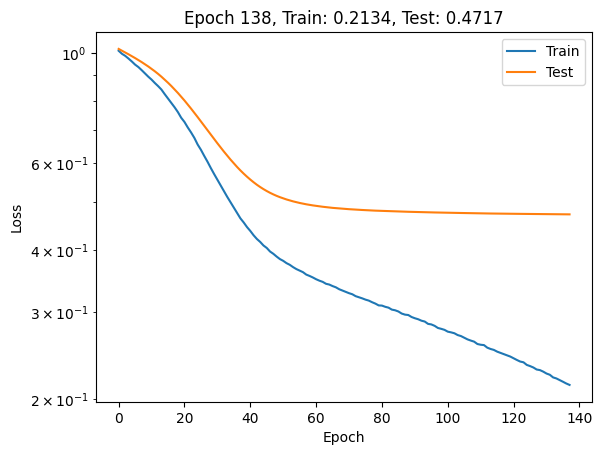

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

learning_rate = 1e-3
batch_size = 64
epochs = 500
train_losses = []
test_losses = []

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)#, verbose=True)

for t in range(epochs):
    train_loss = train_loop(train_dataloader, model, loss_fn, optimizer)
    preds, test_loss = test_loop(test_dataloader, model, loss_fn)
    scheduler.step(test_loss)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    
    clear_output(wait=True)
    plt.plot(train_losses, label='Train')
    plt.plot(test_losses, label='Test')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Epoch {t+1}, Train: {train_loss:.4f}, Test: {test_loss:.4f}')
    plt.legend()
    plt.show()

print("Done!")

In [ ]:
X, y = genrandomfields(10, 1, 50, 50, 100)
X_eval = convert_to_torch_data(X)
X_eval = X_eval.permute(0, 3, 1, 2)
y_eval = convert_to_torch_data(y)
X_eval.to(device)
y_eval.to(device)
y_eval = y_eval[:, :, 0]
y_eval.to(torch.long)
X_eval, _, _ = normalize_data(X_eval)
#y_eval, _, _ = normalize_data(y_eval)

new_dataset = TensorDataset(X_eval, y_eval)
new_dataloader = DataLoader(new_dataset, batch_size=batch_size)

preds, loss = test_loop(new_dataloader, model, loss_fn)

#true_values = torch.cat([y for _, y in new_dataloader], dim=0)

preds = y_train_mean + preds * y_train_std
print(y_eval)
print(preds)